# OOD Metrics Plots

This notebook plots MSP, Energy, and Mahalanobis results for FPR@95 and AUROC.

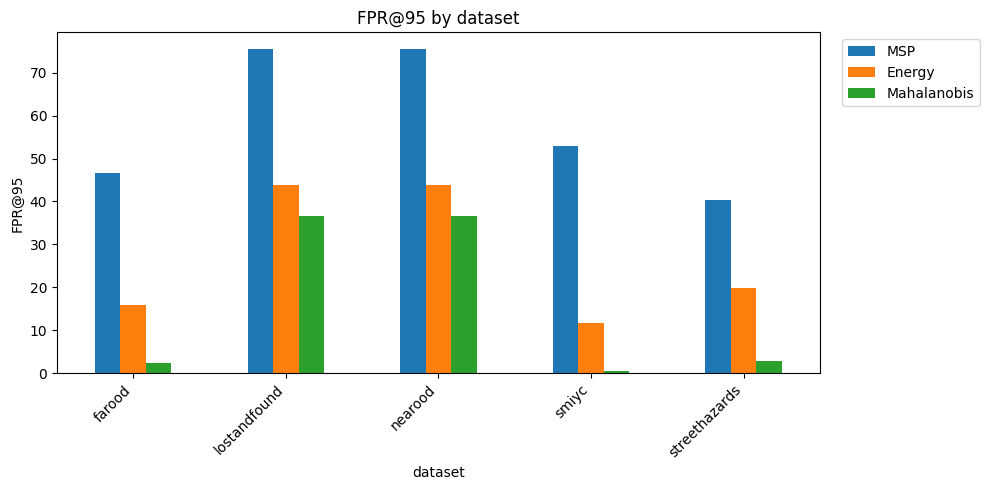

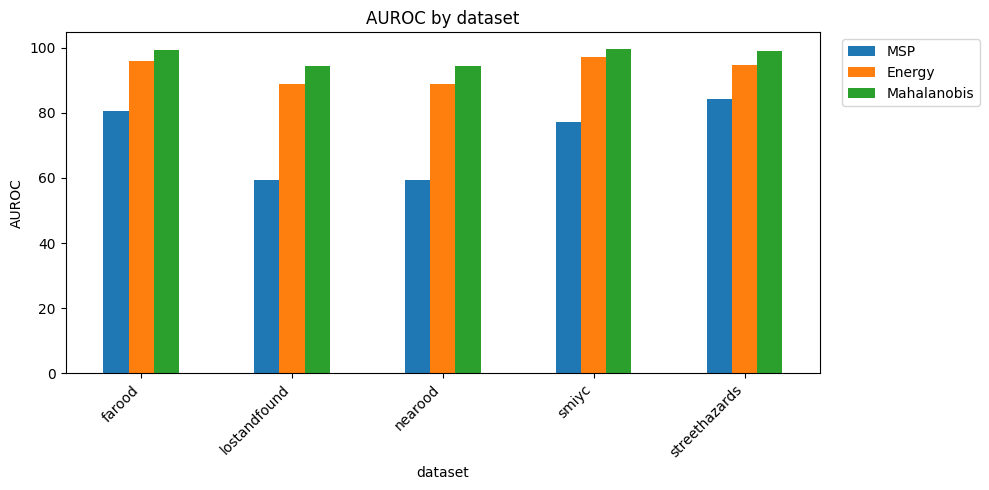

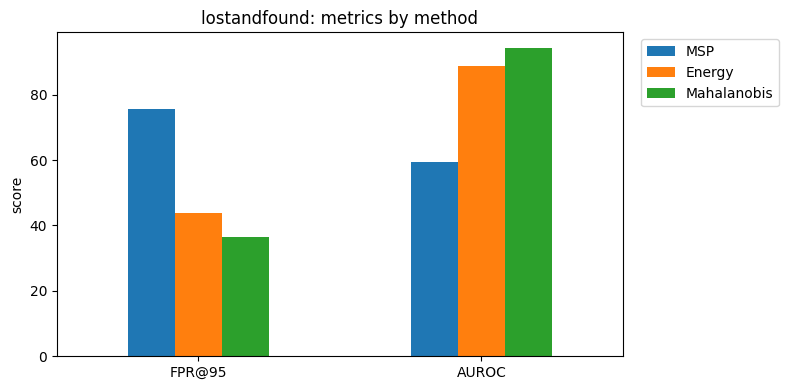

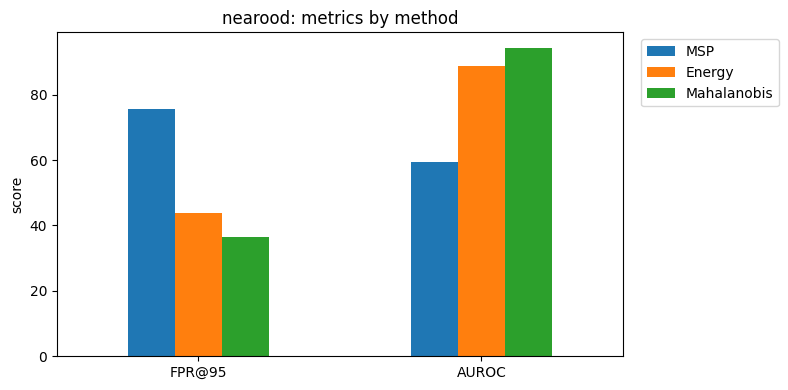

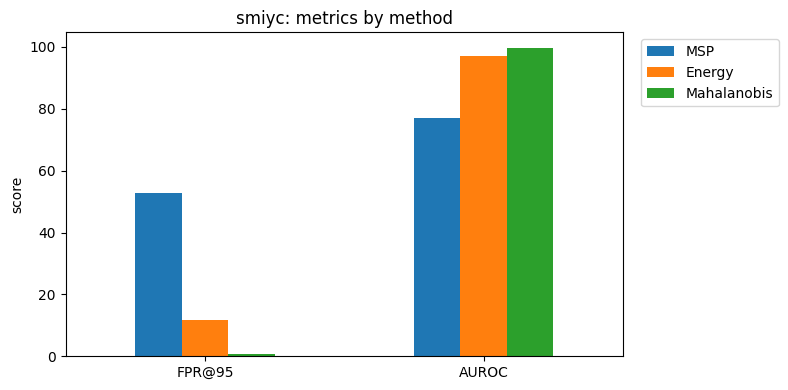

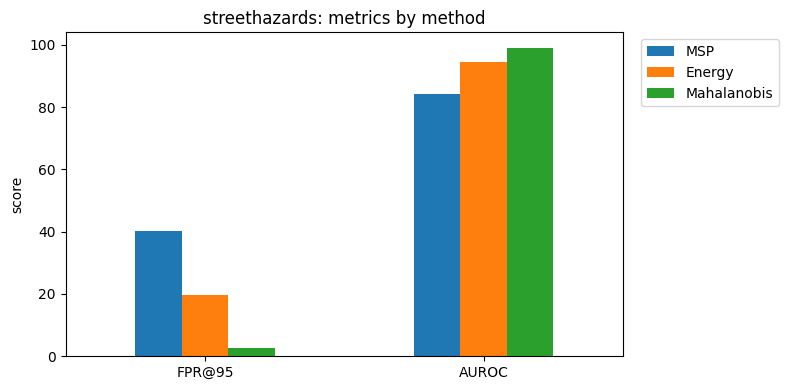

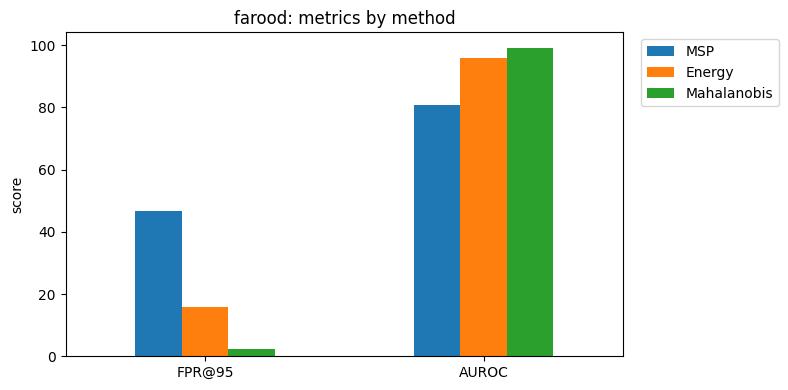

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

data_msp = {
    'dataset': ['lostandfound', 'nearood', 'smiyc', 'streethazards', 'farood'],
    'FPR@95': [75.60, 75.60, 52.91, 40.25, 46.58],
    'AUROC': [59.48, 59.48, 77.18, 84.10, 80.64],
    'AUPR_IN': [93.50, 93.50, 99.06, 97.44, 98.25],
    'AUPR_OUT': [12.04, 12.04, 6.87, 32.78, 19.82],
    'ACC': [82.16, 82.16, 82.16, 82.16, 82.16],
}

data_energy = {
    'dataset': ['lostandfound', 'nearood', 'smiyc', 'streethazards', 'farood'],
    'FPR@95': [43.85, 43.85, 11.80, 19.82, 15.81],
    'AUROC': [88.75, 88.75, 97.05, 94.57, 95.81],
    'AUPR_IN': [98.41, 98.41, 99.89, 99.18, 99.54],
    'AUPR_OUT': [51.46, 51.46, 53.31, 66.14, 59.73],
    'ACC': [82.16, 82.16, 82.16, 82.16, 82.16],
}

data_mds = {
    'dataset': ['lostandfound', 'nearood', 'smiyc', 'streethazards', 'farood'],
    'FPR@95': [36.58, 36.58, 0.58, 2.80, 2.39],
    'AUROC': [94.35, 94.35, 99.73, 99.04, 99.17],
    'AUPR_IN': [99.29, 99.29, 99.99, 99.86, 99.85],
    'AUPR_OUT': [65.27, 65.27, 94.25, 92.31, 94.84],
    'ACC': [82.25, 82.25, 82.25, 82.25, 82.25],
}

def to_df(name, data):
    df = pd.DataFrame(data)
    df['method'] = name
    return df

df = pd.concat([
    to_df('MSP', data_msp),
    to_df('Energy', data_energy),
    to_df('Mahalanobis', data_mds),
], ignore_index=True)

methods = ['MSP', 'Energy', 'Mahalanobis']
method_colors = {
    'MSP': '#1f77b4',
    'Energy': '#ff7f0e',
    'Mahalanobis': '#2ca02c',
}
metrics = ['FPR@95', 'AUROC']
out_dir = Path('/home/ouail.kerrak/ood_project/plots')
out_dir.mkdir(parents=True, exist_ok=True)

# Bar chart per metric (dataset on x-axis, method as grouped bars)
for metric in metrics:
    pivot = df.pivot_table(index='dataset', columns='method', values=metric)
    pivot = pivot[methods]
    ax = pivot.plot(kind='bar', figsize=(10, 5), color=[method_colors[m] for m in methods])
    ax.set_title(f'{metric} by dataset')
    ax.set_ylabel(metric)
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    out_path = out_dir / f"ood_{metric.lower().replace('@', '').replace('%', '')}.png"
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()

# Grouped bars per dataset (metric on x-axis, method as grouped bars)
for dataset in df['dataset'].unique():
    sub = df[df['dataset'] == dataset]
    pivot = sub.set_index('method').loc[methods, metrics].T
    ax = pivot.plot(kind='bar', figsize=(8, 4), color=[method_colors[m] for m in methods])
    ax.set_title(f'{dataset}: metrics by method')
    ax.set_ylabel('score')
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    plt.xticks(rotation=0)
    plt.tight_layout()
    out_path = out_dir / f"ood_grouped_{dataset}.png"
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()

In [8]:
# Comparative table (mean over datasets per method)
table = (
    df.groupby('method')[['FPR@95', 'AUROC', 'AUPR_IN', 'AUPR_OUT', 'ACC']]
    .mean()
    .loc[methods]
    .round(2)
    .reset_index()
    .rename(columns={'method': 'Method'})
 )

table

,Method,FPR@95,AUROC,AUPR_IN,AUPR_OUT,ACC
0,MSP,58.19,72.18,96.35,16.71,82.16
1,Energy,27.03,92.99,99.09,56.42,82.16
2,Mahalanobis,15.79,97.33,99.66,82.39,82.25


In [9]:
# Comparative table by dataset (methods as columns)
table_by_dataset = (
    df.pivot_table(
        index='dataset',
        columns='method',
        values=['FPR@95', 'AUROC', 'AUPR_IN', 'AUPR_OUT', 'ACC']
    )
    .reindex(columns=methods, level=1)
    .round(2)
 )

table_by_dataset

ACC                    AUPR_IN                    AUPR_OUT  \
method           MSP Energy Mahalanobis     MSP Energy Mahalanobis      MSP   
dataset                                                                       
farood         82.16  82.16       82.25   98.25  99.54       99.85    19.82   
lostandfound   82.16  82.16       82.25   93.50  98.41       99.29    12.04   
nearood        82.16  82.16       82.25   93.50  98.41       99.29    12.04   
smiyc          82.16  82.16       82.25   99.06  99.89       99.99     6.87   
streethazards  82.16  82.16       82.25   97.44  99.18       99.86    32.78   

                                  AUROC                    FPR@95         \
method        Energy Mahalanobis    MSP Energy Mahalanobis    MSP Energy   
dataset                                                                    
farood         59.73       94.84  80.64  95.81       99.17  46.58  15.81   
lostandfound   51.46       65.27  59.48  88.75       94.35  75.60  43.85   
nearood        51.46       65.27  59.48  88.75       94.35  75.60  43.85   
smiyc          53.31       94.25  77.18  97.05       99.73  52.91  11.80   
streethazards  66.14       92.31  84.10  94.57       99.04  40.25  19.82   

                           
method        Mahalanobis  
dataset                    
farood               2.39  
lostandfound        36.58  
nearood             36.58  
smiyc                0.58  
streethazards        2.80